# Búscador de Noticias

In [1]:
%pip install sentence-transformers

   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/596.4 kB ? eta -:--:--
   ---------------------------------------- 596.4/596.4 kB 9.1 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


## Librerias

In [4]:
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

## Cargar dataset

In [5]:
path = './data'
filename = '/df_news.csv'
archivo = path + filename

df = pd.read_csv(archivo, sep=',')
df.head()

,news,Type
0,Durante el foro La banca articulador empresari...,Otra
1,El regulador de valores de China dijo el domin...,Regulaciones
2,En una industria históricamente masculina como...,Alianzas
3,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,Ayer en Cartagena se dio inicio a la versión n...,Otra


In [6]:
df.loc[0,'news']

'Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de BBVA en Colombia Andrés García aseguró que es importante entender que la sostenibilidad no la podemos asociar a mayores costos. Yo creo que el no tener un concepto de negocio sostenible puede tener un mayor impacto de lo que imaginamos.Para García el reto más importante es no cambiar prioridades ni que compitan entre sí necesariamente. En muchos de los casos se debe tratar de mantener la prioridad en cuanto a la ambición de negocios más sostenibles un reto enorme por la coyuntura. La sostenibilidad nos abre oportunidades a mejores fuentes de financiamiento agregó.El directivo argumentó que lo que se encuentra en juego acá no es un tema de rentabilidad o de negocios en particular es un tema de viabilidad del mundo de los negocios y del mundo físico en general como lo conocemos. Además los riesgos físicos y de transición asociados al cambio climático y a la

In [7]:
df.loc[1,'news']

'El regulador de valores de China dijo el domingo que buscará una cooperación más estrecha con su par estadounidense y que apoyará las salidas a bolsa en el extranjero luego de que supervisores estadounidenses endurecieron las exigencias de divulgación de información para las empresas chinas y expresaron preocupación por medidas de Pekín.La Comisión Reguladora de Valores de China CSRC dijo en un comunicado que tomó nota de los nuevos requisitos de la Comisión de Valores de Estados Unidos SEC para las empresas chinas y que ambas partes deberían mantener el espíritu de respeto mutuo y reforzar las comunicaciones sobre la regulación.La CSRC siempre ha estado abierta a que las empresas elijan dónde salir a bolsa y la política nacional básica de China de avanzar en la reforma y la apertura es inquebrantable y la apertura financiera al mundo exterior continuará dijo en su sitio web.La SEC había dicho el viernes que exigirá a las compañías chinas que revelen la incertidumbre sobre futuras acc

In [8]:
print(df.shape)

df.head()

(1142, 2)


,news,Type
0,Durante el foro La banca articulador empresari...,Otra
1,El regulador de valores de China dijo el domin...,Regulaciones
2,En una industria históricamente masculina como...,Alianzas
3,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,Ayer en Cartagena se dio inicio a la versión n...,Otra


In [9]:
documentos = df["news"].tolist()

In [10]:
type(documentos)

list

In [11]:
len(documentos)

1142

In [12]:
print(documentos[1][0:300])

El regulador de valores de China dijo el domingo que buscará una cooperación más estrecha con su par estadounidense y que apoyará las salidas a bolsa en el extranjero luego de que supervisores estadounidenses endurecieron las exigencias de divulgación de información para las empresas chinas y expres


## Cargar modelo de embeddings

In [13]:
model = SentenceTransformer(
    'sentence-transformers/all-MiniLM-L6-v2'
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3428.21it/s]


## Generar embeddings

In [14]:
embeddings = model.encode(
    documentos,
    show_progress_bar=True
)

Batches: 100%|██████████| 36/36 [02:16<00:00,  3.78s/it]


## Dimensiones

In [16]:
print(embeddings.shape)

(1142, 384)


1142 noticias
↓
Cada noticia
↓
384 números

In [17]:
type(embeddings)

numpy.ndarray

In [18]:
embeddings[0,:10]

array([ 0.02655157,  0.0082066 , -0.03793216,  0.01148671, -0.0280212 ,
        0.00238347,  0.03936794, -0.00316691,  0.04649591,  0.06377905],
      dtype=float32)

In [19]:
embeddings[1,:10]

array([-0.05751369, -0.00125642, -0.02811901, -0.02961793, -0.00659193,
        0.03702753,  0.06138196, -0.03350011,  0.01803238, -0.03931474],
      dtype=float32)

## Crear consulta

In [20]:
consulta = """
problemas regulatorios de empresas chinas
"""

## Embedding de la consulta

In [21]:
embedding_consulta = model.encode(
    [consulta]
)

## Verificar

In [22]:
print(embedding_consulta.shape)

(1, 384)


In [23]:
embedding_consulta[0,:10]

array([-0.01855797,  0.07129993,  0.00697735,  0.00932621, -0.02448057,
        0.07758469,  0.06049325,  0.00585371,  0.00210488, -0.03469236],
      dtype=float32)

## Calcular similitud del coseno

In [24]:
scores = cosine_similarity(
    embedding_consulta,
    embeddings
)

## Verificar

In [25]:
print(scores.shape)

(1, 1142)


In [26]:
type(scores)

numpy.ndarray

In [27]:
scores

array([[0.41570523, 0.6188787 , 0.23440255, ..., 0.37276536, 0.27837217,
        0.33493787]], shape=(1, 1142), dtype=float32)

## Ordenar resultados

In [28]:
scores = scores.flatten()

top_k = 5

indices = np.argsort(scores)[::-1][:top_k]

## Mostrar Top 5

In [29]:
import textwrap

for rank, idx in enumerate(indices, start=1):

    print("="*100)

    print(f"TOP {rank}")

    print(f"Score: {scores[idx]:.4f}")

    print(f"Categoría: {df.iloc[idx]['Type']}")

    print()

    noticia = df.iloc[idx]["news"][:700]

    print(
        textwrap.fill(
            noticia,
            width=100
        )
    )

    print()

TOP 1
Score: 0.6189
Categoría: Regulaciones

El regulador de valores de China dijo el domingo que buscará una cooperación más estrecha con su par
estadounidense y que apoyará las salidas a bolsa en el extranjero luego de que supervisores
estadounidenses endurecieron las exigencias de divulgación de información para las empresas chinas y
expresaron preocupación por medidas de Pekín.La Comisión Reguladora de Valores de China CSRC dijo en
un comunicado que tomó nota de los nuevos requisitos de la Comisión de Valores de Estados Unidos SEC
para las empresas chinas y que ambas partes deberían mantener el espíritu de respeto mutuo y
reforzar las comunicaciones sobre la regulación.La CSRC siempre ha estado abierta a que las empresas
elijan dón

TOP 2
Score: 0.6086
Categoría: Regulaciones

El regulador bancario de China dijo que las recientes medidas para frenar el monopolio de las
empresas de tecnología financiera y que han afectado fuertemente a gigantes como Ant Group de Jack
Ma no apuntaban

## Automatizar mediante una función

In [30]:
import numpy as np
import textwrap

from sklearn.metrics.pairwise import cosine_similarity


def buscar_noticias(
    consulta,
    model,
    embeddings,
    df,
    top_k=5
):
    """
    Buscador semántico basado en embeddings y similitud del coseno.
    consulta: str
    model: SentenceTransformer
    embeddings: np.array
    df: pd.DataFrame
    top_k: int. Indica cuantas noticias debe mostrar, por defecto 5.
    """

    # Embedding de la consulta
    embedding_consulta = model.encode([consulta])

    # Similitud del coseno
    scores = cosine_similarity(
        embedding_consulta,
        embeddings
    ).flatten()

    # Top K resultados
    indices = np.argsort(scores)[::-1][:top_k]

    print("\n")
    print("="*120)
    print("CONSULTA:")
    print(consulta)
    print("="*120)

    for rank, idx in enumerate(indices, start=1):

        print("\n" + "-"*120)

        print(f"TOP {rank}")

        print(f"Score      : {scores[idx]:.4f}")

        print(f"Categoría  : {df.iloc[idx]['Type']}")

        print("-"*120)

        noticia = df.iloc[idx]["news"][:700]

        print(
            textwrap.fill(
                noticia,
                width=100
            )
        )

        print()

    return indices

## Probar con otras opciones

In [31]:
buscar_noticias(
    consulta="problemas regulatorios de empresas chinas",
    model=model,
    embeddings=embeddings,
    df=df
)



CONSULTA:
problemas regulatorios de empresas chinas

------------------------------------------------------------------------------------------------------------------------
TOP 1
Score      : 0.6189
Categoría  : Regulaciones
------------------------------------------------------------------------------------------------------------------------
El regulador de valores de China dijo el domingo que buscará una cooperación más estrecha con su par
estadounidense y que apoyará las salidas a bolsa en el extranjero luego de que supervisores
estadounidenses endurecieron las exigencias de divulgación de información para las empresas chinas y
expresaron preocupación por medidas de Pekín.La Comisión Reguladora de Valores de China CSRC dijo en
un comunicado que tomó nota de los nuevos requisitos de la Comisión de Valores de Estados Unidos SEC
para las empresas chinas y que ambas partes deberían mantener el espíritu de respeto mutuo y
reforzar las comunicaciones sobre la regulación.La CSRC siempr

array([  1,  14, 719, 400, 376])

In [32]:
buscar_noticias(
    consulta="innovación tecnológica en bancos",
    model=model,
    embeddings=embeddings,
    df=df
)



CONSULTA:
innovación tecnológica en bancos

------------------------------------------------------------------------------------------------------------------------
TOP 1
Score      : 0.7496
Categoría  : Innovacion
------------------------------------------------------------------------------------------------------------------------
La publicación británica The Banker, del grupo Financial Times, ha seleccionado a BBVA como el mejor
banco digital en Europa y América Latina en sus Innovation in Digital Banking Awards. La revista
especializada ha otorgado un tercer premio en esta edición a la mejor colaboración entre un banco y
una ‘fintech’, gracias a la solución biométrica de Veridas para los clientes pensionistas de BBVA
México.  La estrategia de digitalización de la entidad financiera ha demostrado ser una gran ventaja
frente al desafiante escenario en el que los clientes del banco utilizan cada vez más los canales
online. De hecho, los clientes digitales del Grupo han crecido un 3

array([ 384, 1031,  381,  216,   68])

In [33]:
buscar_noticias(
    consulta="alianzas estratégicas entre compañías",
    model=model,
    embeddings=embeddings,
    df=df
)



CONSULTA:
alianzas estratégicas entre compañías

------------------------------------------------------------------------------------------------------------------------
TOP 1
Score      : 0.6147
Categoría  : Innovacion
------------------------------------------------------------------------------------------------------------------------
La entidad ha celebrado una semana dedicada al talento. Los empleados del banco han participado en
diversas actividades, tanto presenciales como online, con el objetivo de conocer y trabajar con las
herramientas que el banco pone a su disposición para su formación y desarrollo profesional.  Con
motivo de esta semana especial dedicada al talento, los especialistas de Talento y Cultura se
desplegaron, tanto en las sedes corporativas como en las oficinas comerciales, para explicar las
oportunidades de crecimiento que existen dentro de la organización.  “El entorno de trabajo tiene
que propiciar que el talento pueda florecer, y para ello el trabajo de l

array([ 822,  498,  416, 1048,   65])

In [34]:
buscar_noticias(
    consulta="como se hace una tarta de chocolate",
    model=model,
    embeddings=embeddings,
    df=df
)



CONSULTA:
como se hace una tarta de chocolate

------------------------------------------------------------------------------------------------------------------------
TOP 1
Score      : 0.5865
Categoría  : Innovacion
------------------------------------------------------------------------------------------------------------------------
La gamificación (o ludificación) es una técnica de aprendizaje que fomenta la adquisición o
consolidación de conocimientos mediante juegos, estimulando la motivación y la productividad. España
es una potencia de primer orden en esta técnica y BBVA se sitúa como referente a nivel mundial de la
gamificación en banca.  A principios de la década de 2010, la popular marca de ‘snacks’ de chocolate
M&M’s lanzó al mercado una versión de sus dulces con sabor a ‘pretzel’, galleta salada con forma de
lazo típica del centro de Europa. Para impulsar sus ventas, divulgaron a través de Facebook una
peculiar campaña de promoción. Solo se trataba de una imagen. Un jue

array([362, 140, 986, 248, 341])

In [35]:
todos = np.vstack([
    embedding_consulta,
    embeddings[indices]
])

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

coords = pca.fit_transform(todos)


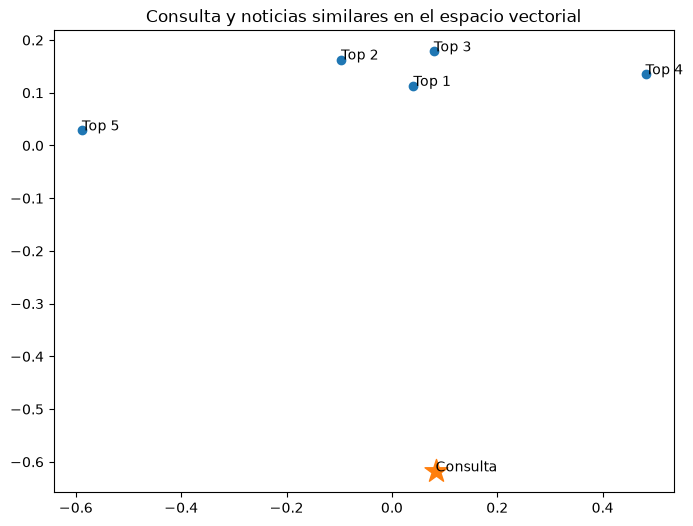

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    coords[1:,0],
    coords[1:,1]
)

plt.scatter(
    coords[0,0],
    coords[0,1],
    marker="*",
    s=300
)

plt.annotate(
    "Consulta",
    (coords[0,0], coords[0,1])
)

for i in range(1, len(coords)):

    plt.annotate(
        f"Top {i}",
        (coords[i,0], coords[i,1])
    )

plt.title(
    "Consulta y noticias similares en el espacio vectorial"
)

plt.show()

Los embeddings viven en un espacio de 384 dimensiones. PCA nos permite proyectarlos a dos dimensiones para visualizar cómo la IA agrupa conceptos con significado similar.

In [41]:
path = 'C:/_aTrabajo/_Projects/TheBridge/individual/bootcamp_AI_copia_local_RMO/05_RAG_Engineering/Sprint_08/Practica_live_review'
filename = '/embeddings.npy'
archivo = path + filename

In [42]:
np.save(
    archivo,
    embeddings
)

In [ ]:
!pip show sentence-transformers

Name: sentence-transformers
Version: 5.5.1
Summary: Embeddings, Retrieval, and Reranking
Home-page: https://www.SBERT.net
Author: 
Author-email: Nils Reimers <info@nils-reimers.de>, Tom Aarsen <tom.aarsen@huggingface.co>
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: huggingface-hub, numpy, scikit-learn, scipy, torch, tqdm, transformers, typing_extensions
Required-by: 
